Лабораторная работа номер 2

Автоматизация подбора персонала с помощью методов машинного обучения

**Источник данных:** https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset

Выполнил: Бутин Владислав
Группа: ИДБ-22-12

In [2]:
!pip install wordcloud nltk scikit-learn pandas numpy matplotlib seaborn joblib kaggle

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
import joblib
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from scipy.sparse import hstack, csr_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
df = pd.read_csv('resume_data/Resume/Resume.csv')
print(f"✅ Загружено {len(df)} резюме")
print(f"Колонки: {df.columns.tolist()}")
df.head()

✅ Загружено 2484 резюме
Колонки: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


Распределение по категориям:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


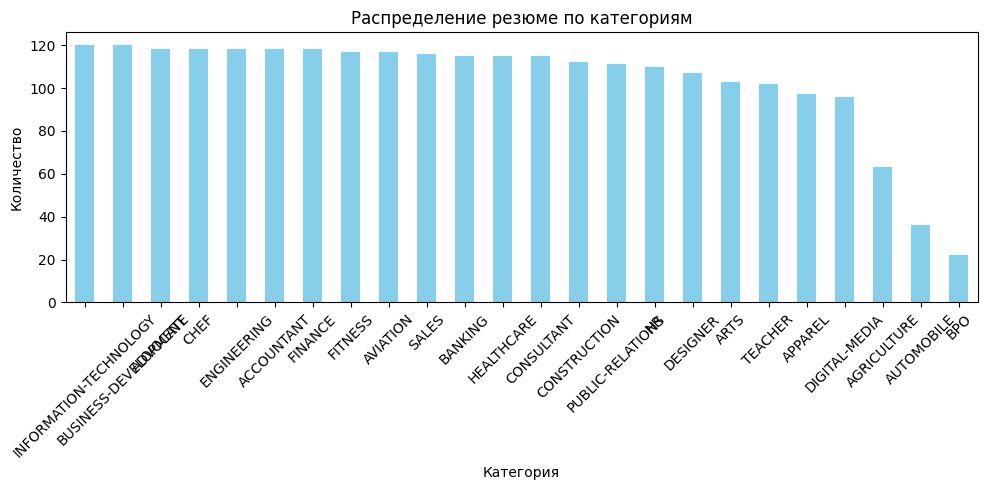

In [17]:
# Анализ распределения по категориям
print("Распределение по категориям:")
print(df['Category'].value_counts())

# Визуализация
plt.figure(figsize=(10, 5))
df['Category'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Распределение резюме по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Распределение целевой переменной:
target
1    1280
0    1204
Name: count, dtype: int64
Доля менеджеров: 51.5%
Доля специалистов: 48.5%


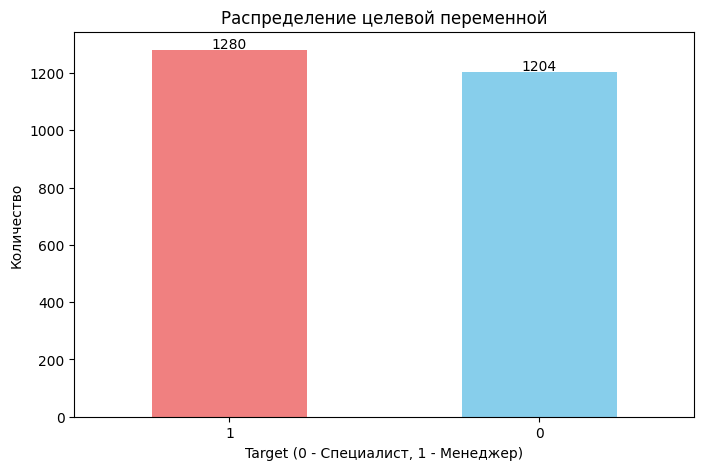

In [20]:
# Создадим целевую переменную н"HR-менеджеры" и "HR-специалисты"

# Ключевые слова для разных уровней
management_keywords = ['manager', 'director', 'lead', 'supervisor', 'chief', 'head', 'executive']
specialist_keywords = ['specialist', 'coordinator', 'assistant', 'clerk', 'associate', 'generalist', 'intern']

def determine_target(resume_text):
    text = str(resume_text).lower()

    management_count = sum(1 for kw in management_keywords if kw in text)
    specialist_count = sum(1 for kw in specialist_keywords if kw in text)

    if management_count > specialist_count:
        return 1
    else:
        return 0

df['target'] = df['Resume_str'].apply(determine_target)

print("Распределение целевой переменной:")
print(df['target'].value_counts())
print(f"Доля менеджеров: {df['target'].mean()*100:.1f}%")
print(f"Доля специалистов: {(1-df['target'].mean())*100:.1f}%")

plt.figure(figsize=(8, 5))
df['target'].value_counts().plot(kind='bar', color=['lightcoral', 'skyblue'])
plt.title('Распределение целевой переменной')
plt.xlabel('Target (0 - Специалист, 1 - Менеджер)')
plt.ylabel('Количество')
plt.xticks(rotation=0)
for i, v in enumerate(df['target'].value_counts().values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

Статистика длины резюме:
count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: resume_length, dtype: float64


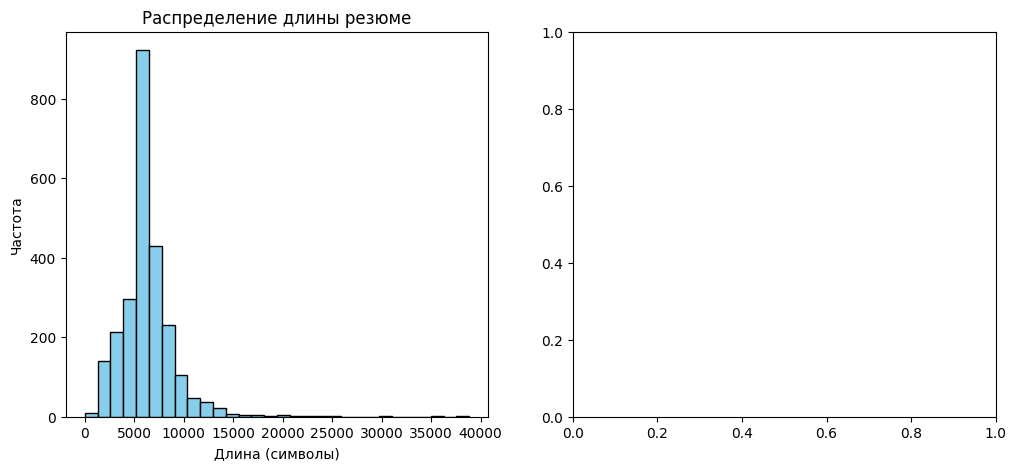

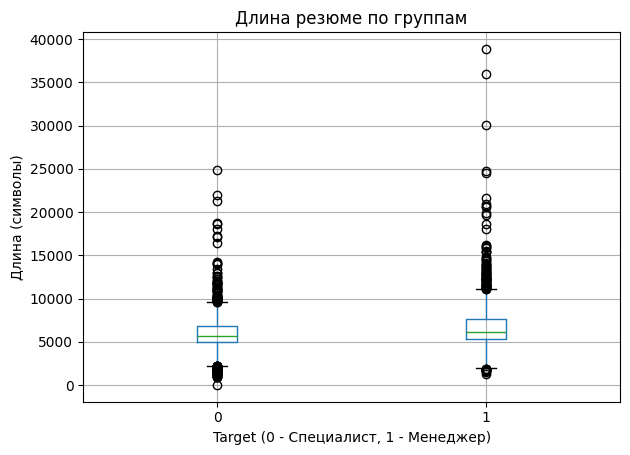

In [21]:
df['resume_length'] = df['Resume_str'].str.len()
print("Статистика длины резюме:")
print(df['resume_length'].describe())

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['resume_length'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение длины резюме')
plt.xlabel('Длина (символы)')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
df.boxplot(column='resume_length', by='target')
plt.title('Длина резюме по группам')
plt.suptitle('')
plt.xlabel('Target (0 - Специалист, 1 - Менеджер)')
plt.ylabel('Длина (символы)')

plt.tight_layout()
plt.show()

In [22]:
def get_top_words(text_series, n=20):
    all_text = ' '.join(text_series.astype(str)).lower()
    # Простая токенизация по пробелам
    words = all_text.split()
    # Убираем короткие слова и стоп-слова
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if len(w) > 3 and w not in stop_words]
    return Counter(words).most_common(n)

print("Топ-20 слов в резюме менеджеров (target=1):")
manager_words = get_top_words(df[df['target']==1]['Resume_str'])
for word, count in manager_words[:10]:
    print(f"  {word}: {count}")

print("\nТоп-20 слов в резюме специалистов (target=0):")
specialist_words = get_top_words(df[df['target']==0]['Resume_str'])
for word, count in specialist_words[:10]:
    print(f"  {word}: {count}")

Топ-20 слов в резюме менеджеров (target=1):
  state: 8205
  city: 7655
  company: 7539
  name: 6024
  management: 4895
  business: 4861
  sales: 4064
  customer: 3751
  team: 3107
  project: 3055

Топ-20 слов в резюме специалистов (target=0):
  state: 7730
  city: 7322
  company: 6622
  name: 5634
  customer: 3704
  management: 3121
  skills: 2961
  experience: 2410
  business: 2302
  sales: 2302


In [24]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Очистка и лемматизация текста"""
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)

    tokens = text.split()

    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

sample_idx = 0
df['clean_text'] = df['Resume_str'].apply(preprocess_text)

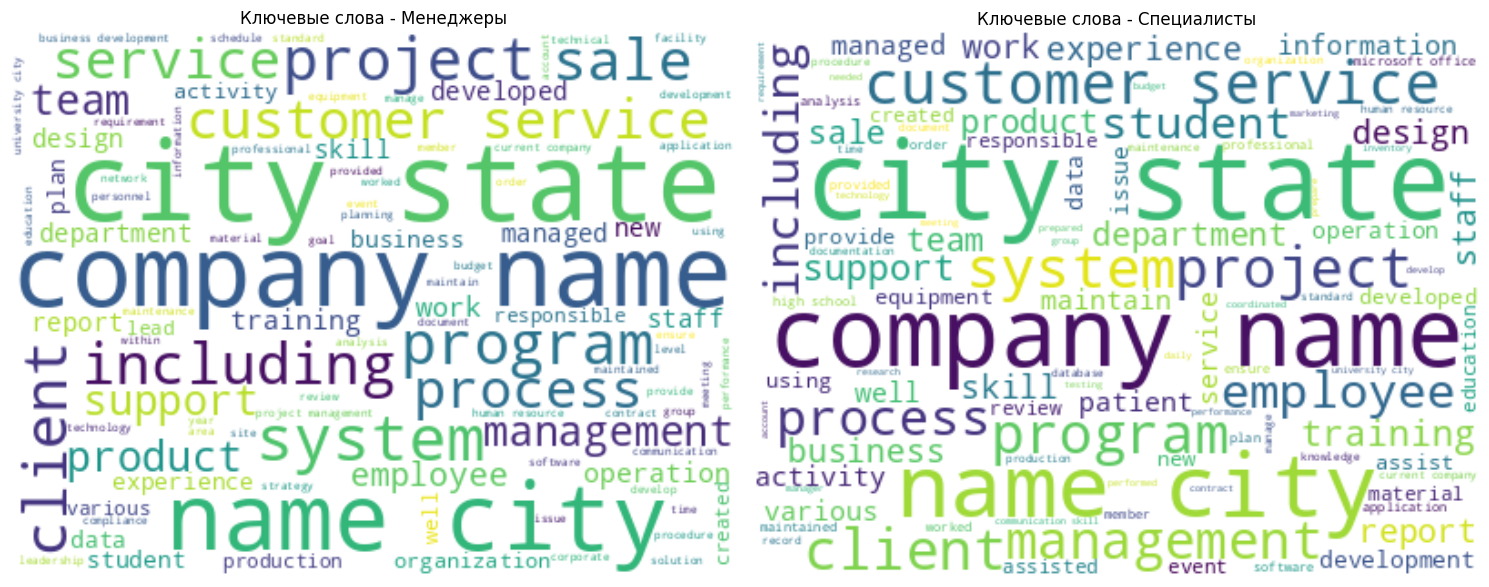

In [25]:
def plot_wordcloud(text_series, title, ax):
    all_text = ' '.join(text_series.astype(str))
    if not all_text.strip():
        ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)
        ax.set_title(title)
        ax.axis('off')
        return

    wordcloud = WordCloud(width=400, height=300,
                         background_color='white',
                         max_words=100,
                         colormap='viridis').generate(all_text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)

# Создаем облака слов
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_wordcloud(df[df['target']==1]['clean_text'], 'Ключевые слова - Менеджеры', axes[0])
plot_wordcloud(df[df['target']==0]['clean_text'], 'Ключевые слова - Специалисты', axes[1])

plt.tight_layout()
plt.show()

In [26]:
vectorizer = TfidfVectorizer(max_features=500, min_df=2, max_df=0.9)
X_text = vectorizer.fit_transform(df['clean_text'])
print(f"Размер TF-IDF матрицы: {X_text.shape}")
print(f"Количество уникальных признаков: {len(vectorizer.get_feature_names_out())}")

# Посмотрим на самые важные слова
feature_names = vectorizer.get_feature_names_out()
print("\nПримеры признаков (первые 20):")
print(feature_names[:20])

Размер TF-IDF матрицы: (2484, 500)
Количество уникальных признаков: 500

Примеры признаков (первые 20):
['ability' 'access' 'accomplishment' 'account' 'accountant' 'accounting'
 'accuracy' 'accurate' 'across' 'action' 'activity' 'additional'
 'administration' 'administrative' 'advanced' 'advertising' 'agency'
 'also' 'analysis' 'analyst']


In [27]:
# Ключевые слова для разных HR-ролей
keywords = {
    'management': ['manager', 'director', 'lead', 'supervisor', 'executive', 'head', 'chief'],
    'specialist': ['specialist', 'coordinator', 'assistant', 'clerk', 'associate', 'generalist'],
    'skills_hr': ['recruitment', 'benefits', 'payroll', 'employee relations', 'training',
                  'compensation', 'fmla', 'compliance', 'hiring', 'onboarding'],
    'skills_soft': ['communication', 'leadership', 'team', 'project', 'strategic', 'planning'],
    'education': ['bachelor', 'master', 'mba', 'phd', 'degree', 'certification']
}

# Создаем признаки для каждой группы
for group_name, kw_list in keywords.items():
    for kw in kw_list:
        col_name = f'has_{group_name}_{kw.replace(" ", "_")}'
        df[col_name] = df['clean_text'].str.contains(kw).astype(int)

# Собираем все бинарные признаки
keyword_features = [col for col in df.columns if col.startswith('has_')]
print(f"Создано {len(keyword_features)} бинарных признаков")
print("\nПримеры признаков:")
print(keyword_features[:10])

Создано 35 бинарных признаков

Примеры признаков:
['has_management_manager', 'has_management_director', 'has_management_lead', 'has_management_supervisor', 'has_management_executive', 'has_management_head', 'has_management_chief', 'has_specialist_specialist', 'has_specialist_coordinator', 'has_specialist_assistant']


In [28]:
# TF-IDF признаки
X_text = vectorizer.fit_transform(df['clean_text'])

# Бинарные признаки
X_keywords = df[keyword_features].fillna(0).values

# Объединяем все признаки
X = hstack([X_text, csr_matrix(X_keywords)])
y = df['target'].values

print(f"Итоговая размерность матрицы признаков: {X.shape}")
print(f"Количество образцов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Распределение классов: {np.bincount(y)}")

Итоговая размерность матрицы признаков: (2484, 535)
Количество образцов: 2484
Количество признаков: 535
Распределение классов: [1204 1280]


In [29]:
# Проверяем, что есть оба класса
if len(np.unique(y)) < 2:
    raise ValueError("❌ В данных только один класс! Нужно изменить способ создания целевой переменной.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов в train: {np.bincount(y_train)}")
print(f"Распределение классов в test: {np.bincount(y_test)}")

Размер обучающей выборки: (1987, 535)
Размер тестовой выборки: (497, 535)
Распределение классов в train: [ 963 1024]
Распределение классов в test: [241 256]


In [31]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]


all_feature_names = list(vectorizer.get_feature_names_out()) + keyword_features
coef = lr_model.coef_[0]
feat_coef = list(zip(all_feature_names[:len(coef)], coef))

pos_coef = sorted(feat_coef, key=lambda x: x[1], reverse=True)[:10]
for feat, c in pos_coef:
    print(f"  {feat}: {c:.4f}")

neg_coef = sorted(feat_coef, key=lambda x: x[1])[:10]
for feat, c in neg_coef:
    print(f"  {feat}: {c:.4f}")

  has_management_manager: 3.6010
  has_management_lead: 3.4570
  has_management_director: 3.4243
  has_management_supervisor: 3.4084
  has_management_chief: 3.0625
  has_management_head: 2.9623
  has_management_executive: 2.7634
  construction: 0.9550
  patient: 0.7821
  guest: 0.7652
  has_specialist_assistant: -3.5022
  has_specialist_specialist: -3.3150
  has_specialist_associate: -3.1466
  has_specialist_coordinator: -3.0264
  has_specialist_clerk: -2.8503
  has_specialist_generalist: -2.3476
  internal: -1.5623
  international: -1.5109
  billing: -0.8056
  security: -0.7880


In [33]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15,
                                   random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Важность признаков
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-20:]

for i in indices:
    print(f"  {all_feature_names[i]}: {importances[i]:.4f}")

  leadership: 0.0060
  has_management_supervisor: 0.0062
  supervisor: 0.0063
  has_specialist_specialist: 0.0064
  coordinator: 0.0070
  has_specialist_coordinator: 0.0078
  has_management_head: 0.0088
  lead: 0.0088
  executive: 0.0116
  associate: 0.0125
  has_management_executive: 0.0127
  specialist: 0.0129
  has_specialist_associate: 0.0145
  assistant: 0.0147
  has_specialist_assistant: 0.0174
  director: 0.0183
  has_management_lead: 0.0219
  has_management_manager: 0.0223
  has_management_director: 0.0270
  manager: 0.0331


In [ ]:
models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf
}

results = []
for model_name, y_pred in models.items():
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    results.append(metrics)

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"  Детальный отчет:")
    print(classification_report(y_test, y_pred, target_names=['Специалист', 'Менеджер']))

# Сравнительная таблица
results_df = pd.DataFrame(results)
print("\n📊 Сводная таблица метрик:")
print(results_df.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
metrics_plot = results_df.melt(id_vars=['Model'],
                                value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                                var_name='Metric', value_name='Score')

sns.barplot(data=metrics_plot, x='Metric', y='Score', hue='Model')
plt.title('Сравнение метрик моделей', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
def plot_confusion_matrices(y_true, y_pred_lr, y_pred_rf):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Логистическая регрессия
    cm_lr = confusion_matrix(y_true, y_pred_lr)
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Матрица ошибок - Логистическая регрессия', fontsize=12)
    axes[0].set_xlabel('Предсказанный класс')
    axes[0].set_ylabel('Истинный класс')
    axes[0].set_xticklabels(['Специалист', 'Менеджер'])
    axes[0].set_yticklabels(['Специалист', 'Менеджер'])

    # Случайный лес
    cm_rf = confusion_matrix(y_true, y_pred_rf)
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title('Матрица ошибок - Random Forest', fontsize=12)
    axes[1].set_xlabel('Предсказанный класс')
    axes[1].set_ylabel('Истинный класс')
    axes[1].set_xticklabels(['Специалист', 'Менеджер'])
    axes[1].set_yticklabels(['Специалист', 'Менеджер'])

    plt.tight_layout()
    plt.show()

    # Анализ
    print("\n📊 Анализ матриц ошибок:")
    print(f"Логистическая регрессия:")
    print(f"  ✅ Верно предсказанные специалисты: {cm_lr[0,0]}")
    print(f"  ❌ Специалисты, ошибочно определенные как менеджеры: {cm_lr[0,1]}")
    print(f"  ❌ Менеджеры, ошибочно определенные как специалисты: {cm_lr[1,0]}")
    print(f"  ✅ Верно предсказанные менеджеры: {cm_lr[1,1]}")

    print(f"\nRandom Forest:")
    print(f"  ✅ Верно предсказанные специалисты: {cm_rf[0,0]}")
    print(f"  ❌ Специалисты, ошибочно определенные как менеджеры: {cm_rf[0,1]}")
    print(f"  ❌ Менеджеры, ошибочно определенные как специалисты: {cm_rf[1,0]}")
    print(f"  ✅ Верно предсказанные менеджеры: {cm_rf[1,1]}")

plot_confusion_matrices(y_test, y_pred_lr, y_pred_rf)

In [ ]:
# Создаем тестовый DataFrame для анализа
test_indices = range(len(y_test))
test_df = df.iloc[test_indices].copy()
test_df['y_true'] = y_test
test_df['y_pred_rf'] = y_pred_rf

# Анализ по длине резюме
print("📊 Анализ точности модели по длине резюме:")

# Создаем группы по длине
test_df['length_group'] = pd.cut(
    test_df['resume_length'],
    bins=[0, 1000, 2000, 3000, 5000, 10000],
    labels=['<1000', '1000-2000', '2000-3000', '3000-5000', '>5000']
)

length_recall = test_df.groupby('length_group').apply(
    lambda x: recall_score(x['y_true'], x['y_pred_rf']) if len(x) > 0 else 0
)
print("\nRecall по группам длины резюме:")
print(length_recall)

# Визуализация
plt.figure(figsize=(10, 5))
length_recall.plot(kind='bar', color='skyblue')
plt.title('Recall по группам длины резюме', fontsize=14)
plt.xlabel('Длина резюме (символы)')
plt.ylabel('Recall')
plt.xticks(rotation=45)
plt.ylim(0, 1)
for i, v in enumerate(length_recall.values):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

In [ ]:
def predict_hr_role(resume_text, model=rf_model, vectorizer=vectorizer, keyword_features_list=keyword_features):
    """
    Функция для предсказания роли кандидата

    Parameters:
    -----------
    resume_text : str
        Текст резюме
    model : model
        Обученная модель
    vectorizer : TfidfVectorizer
        Обученный векторизатор
    keyword_features_list : list
        Список ключевых слов для признаков

    Returns:
    --------
    dict: Результат предсказания
    """
    try:
        # Предобработка текста
        text_clean = preprocess_text(resume_text)

        # TF-IDF векторизация
        X_text = vectorizer.transform([text_clean])

        # Создание бинарных признаков
        binary_features = []
        for feat_name in keyword_features_list:
            # Извлекаем ключевое слово из названия признака
            # Формат: has_group_keyword
            parts = feat_name.split('_')
            if len(parts) >= 3:
                keyword = parts[2]  # Берем третью часть
                binary_features.append(1 if keyword in text_clean else 0)
            else:
                binary_features.append(0)

        # Объединение признаков
        X = hstack([X_text, csr_matrix([binary_features])])

        # Предсказание
        proba = model.predict_proba(X)[0]
        prediction = model.predict(X)[0]

        return {
            'prediction': 'HR Менеджер' if prediction == 1 else 'HR Специалист',
            'probability': float(proba[1]),
            'confidence': float(max(proba))
        }

    except Exception as e:
        return {'error': str(e)}

# Тестирование функции
test_resumes = [
    """HR Manager with 10+ years of experience in strategic planning, team leadership, and organizational development.
    Managed a team of 15 HR professionals and implemented company-wide training programs.""",

    """HR Specialist focusing on recruitment and onboarding. Experienced in conducting interviews,
    processing new hire paperwork, and coordinating orientation sessions."""
]

print("🧪 Тестирование функции predict_hr_role:")
for i, resume in enumerate(test_resumes, 1):
    result = predict_hr_role(resume)
    print(f"\nРезюме {i}:")
    print(f"  Результат: {result['prediction']}")
    print(f"  Вероятность: {result['probability']:.3f}")
    print(f"  Уверенность: {result['confidence']:.3f}")

In [ ]:
# Сохраняем лучшую модель (выбираем по F1-score)
best_f1_lr = f1_score(y_test, y_pred_lr)
best_f1_rf = f1_score(y_test, y_pred_rf)

if best_f1_rf > best_f1_lr:
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = lr_model
    best_model_name = "Logistic Regression"

print(f"🏆 Лучшая модель: {best_model_name} (F1-score = {max(best_f1_lr, best_f1_rf):.3f})")

# Сохраняем модель и векторизатор
joblib.dump(best_model, 'best_hr_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(keyword_features, 'keyword_features.pkl')

print("✅ Модель и векторизатор сохранены")